# Brain Tumour Object Detection

## 1. Download the Dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("pkdarabi/medical-image-dataset-brain-tumor-detection", 
                                  output_dir="./dataset")

print("Path to dataset files:", path)

Path to dataset files: ./dataset


## 2. Visualizing the Dataset

In [3]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics.utils.plotting import Annotator

In [4]:
# We will use the YOLOv11 model for this project, so we need to use the YOLOv11 dataset format.
dataset_path = path + "/BrainTumor/BrainTumorYolov11"

In [5]:
label_mapping = {
    0: "glioma",
    1: "meningioma",
    2: "pituitary"
}

In [6]:
def convert_to_yolo_bbox(label):
    parts = label.split()
    class_id = parts[0]
    points = list(map(float, parts[1:]))
    
    xs = points[0::2]
    ys = points[1::2]
    x_min = min(xs)
    y_min = min(ys)
    x_max = max(xs)
    y_max = max(ys)

    x_center = (x_min + x_max) / 2
    y_center = (y_min + y_max) / 2
    width = x_max - x_min
    height = y_max - y_min
    
    return class_id, x_center, y_center, width, height

In [7]:
# Display the first 10 images and their corresponding labels
def display_image_with_label(image_data, label_data, type):
    fig, axes = plt.subplots(2, 5, figsize=(20, 8))
    fig.suptitle(f"Sample Images and Labels from the {type} Dataset", fontsize=16)
    for ax, i in zip(axes.flatten(), list(image_data.keys())[:11]):
        annotator = Annotator(image_data[i])

        # Convert YOLO format to bounding box coordinates
        class_id, x_center, y_center, width, height = convert_to_yolo_bbox(label_data[i])

        x1 = int((x_center - width / 2) * image_data[i].shape[1])
        y1 = int((y_center - height / 2) * image_data[i].shape[0])
        x2 = int((x_center + width / 2) * image_data[i].shape[1])
        y2 = int((y_center + height / 2) * image_data[i].shape[0])

        annotator.box_label([x1, y1, x2, y2], label=f'{label_mapping[int(class_id)]}', 
                            color=(0, 255, 0), txt_color=(0, 0, 0))

        # Display the image with the bounding box
        ax.imshow(cv2.cvtColor(annotator.result(), cv2.COLOR_BGR2RGB))
        ax.axis("off")
    plt.tight_layout()
    plt.show()

In [8]:
# Get the label distribution in the given dataset
def display_label_distribution(label_data, type):
    label_counts = {label: 0 for label in label_mapping.values()}
    for label in label_data.values():
        class_id = int(label.split()[0])
        label_counts[label_mapping[class_id]] += 1

    plt.bar(label_counts.keys(), label_counts.values(), color=['blue', 'orange', 'green'])
    plt.title(f"Label Distribution in the {type} Dataset")
    plt.xlabel("Tumor Type")
    plt.ylabel("Count")
    plt.show()

### 2.1 Visualize the Training Dataset

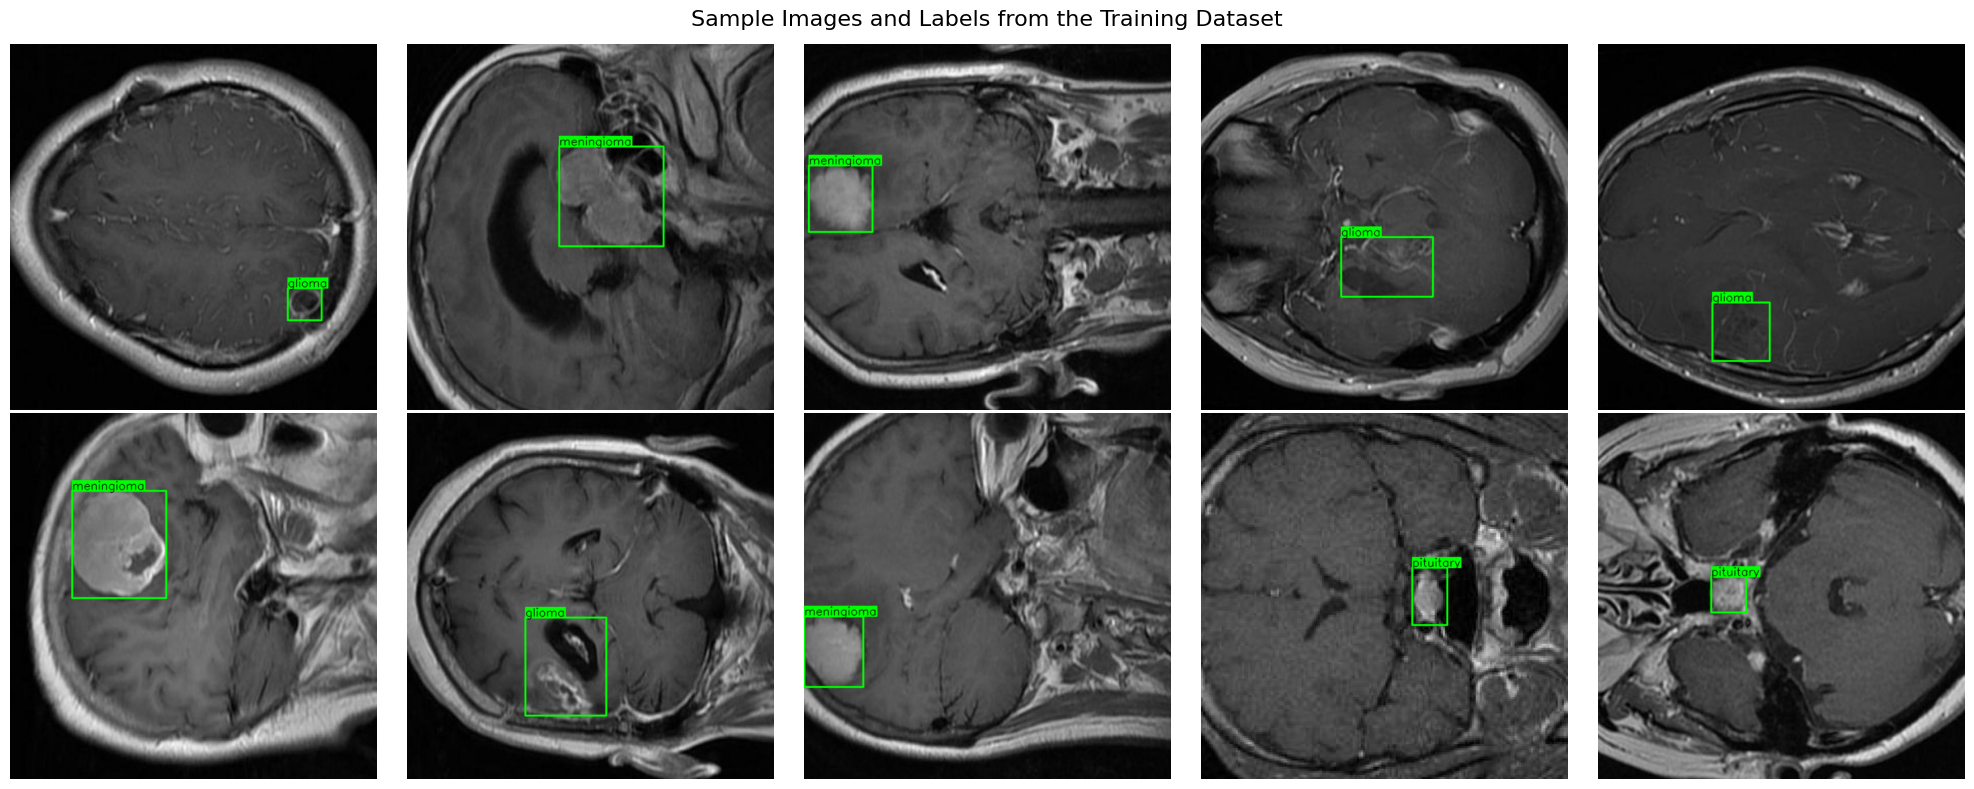

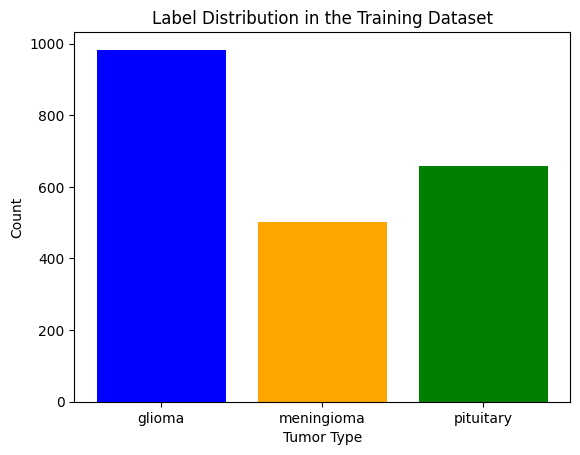

In [9]:
# Load the training dataset
train_images = {}
train_labels = {}
for filename in os.listdir(dataset_path + "/train/images"):
    if filename.endswith(".jpg"):
        index = filename.split("_")[0]

        # Load the image
        img = cv2.imread(os.path.join(dataset_path + "/train/images", filename))
        train_images[index] = img
        
        # Load the corresponding label
        label_filename = filename.replace(".jpg", ".txt")
        with open(os.path.join(dataset_path + "/train/labels", label_filename), "r") as f:
            label = f.read().strip()
            train_labels[index] = label
display_image_with_label(train_images, train_labels, "Training")
display_label_distribution(train_labels, "Training")

### 2.2 Visualize the Test Dataset

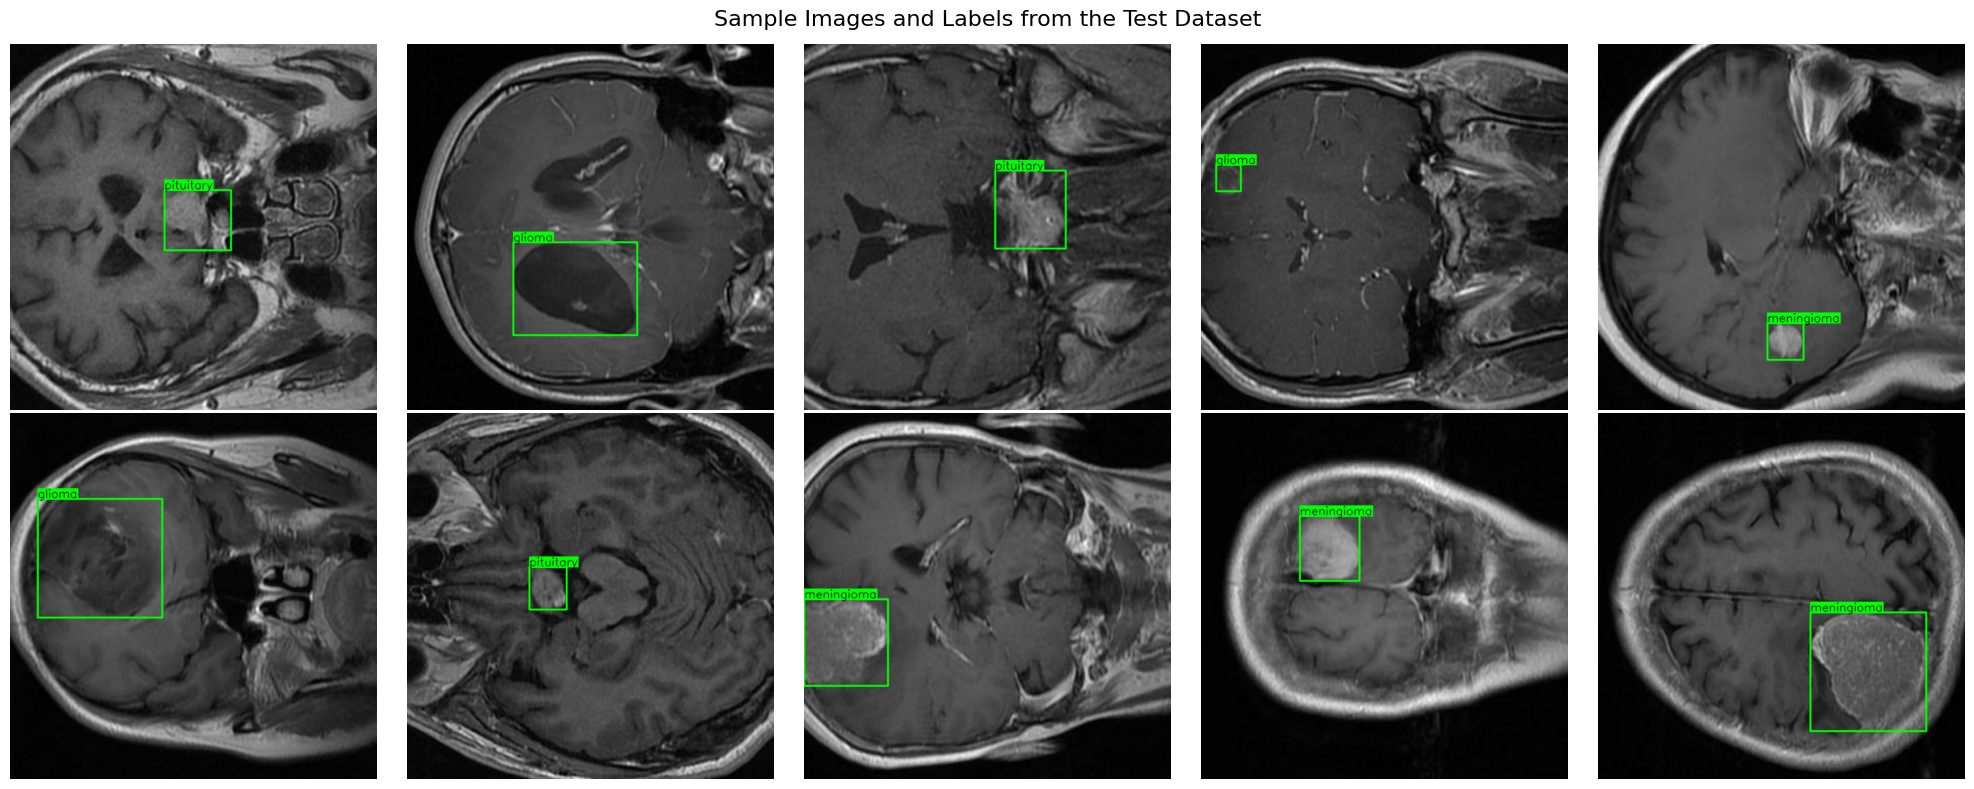

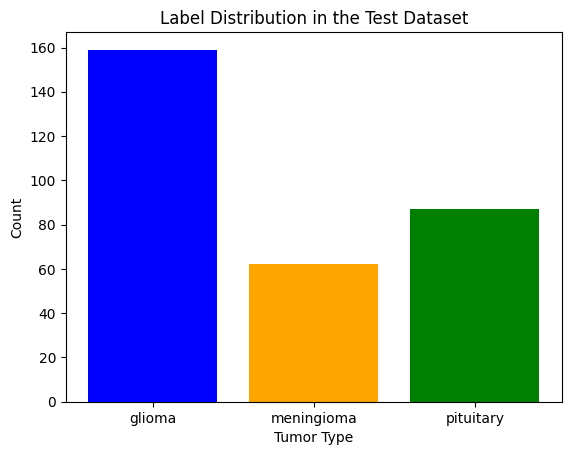

In [10]:
# Load the training dataset
test_images = {}
test_labels = {}
for filename in os.listdir(dataset_path + "/test/images"):
    if filename.endswith(".jpg"):
        index = filename.split("_")[0]

        # Load the image
        img = cv2.imread(os.path.join(dataset_path + "/test/images", filename))
        test_images[index] = img
        
        # Load the corresponding label
        label_filename = filename.replace(".jpg", ".txt")
        with open(os.path.join(dataset_path + "/test/labels", label_filename), "r") as f:
            label = f.read().strip()
            test_labels[index] = label
display_image_with_label(test_images, test_labels, "Test")
display_label_distribution(test_labels, "Test")

### 2.3 Visualize the Validation Dataset

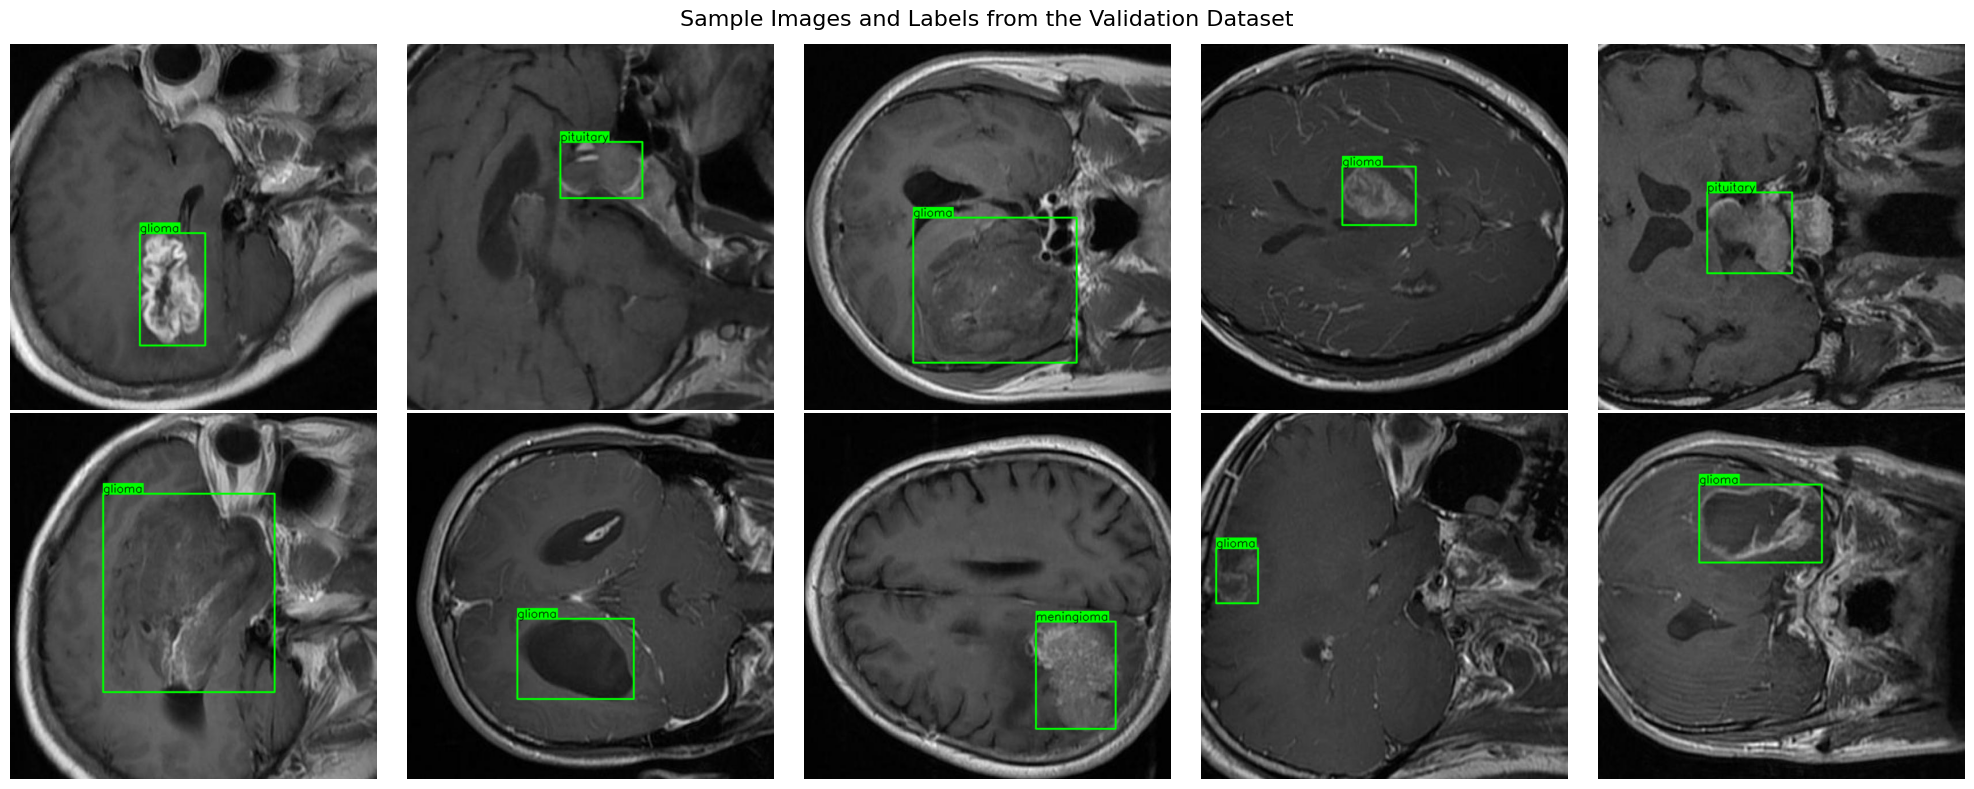

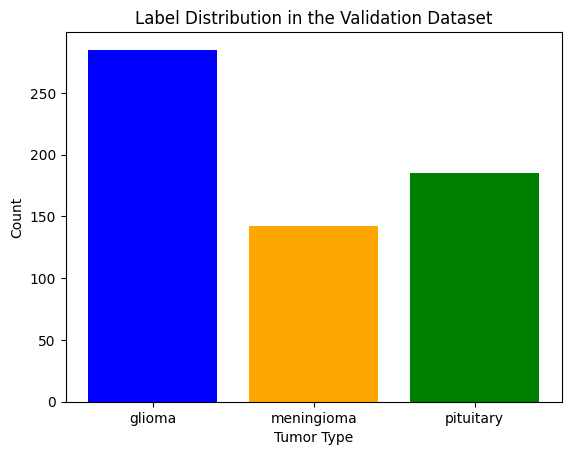

In [11]:
# Load the training dataset
val_images = {}
val_labels = {}
for filename in os.listdir(dataset_path + "/valid/images"):
    if filename.endswith(".jpg"):
        index = filename.split("_")[0]

        # Load the image
        img = cv2.imread(os.path.join(dataset_path + "/valid/images", filename))
        val_images[index] = img
        
        # Load the corresponding label
        label_filename = filename.replace(".jpg", ".txt")
        with open(os.path.join(dataset_path + "/valid/labels", label_filename), "r") as f:
            label = f.read().strip()
            val_labels[index] = label
display_image_with_label(val_images, val_labels, "Validation")
display_label_distribution(val_labels, "Validation")

## 3. Model Training

In [12]:
from ultralytics import YOLO

# Load the YOLOv11 model
model = YOLO("yolo11n.pt")

In [14]:
yaml_path = os.path.join(dataset_path, "data.yaml")

# Train the model
model.train(data=yaml_path, epochs=50, imgsz=640, batch=16, resume=True,
                name="brain_tumor_yolo11n", device=0, optimizer="AdamW")

WARNING ⚠️ model 'yolo11n.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.37 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=./dataset/BrainTumor/BrainTumorYolov11/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask

Exception in thread Thread-14 (_pin_memory_loop):
Traceback (most recent call last):
  File "/usr/lib/python3.10/threading.py", line 1016, in _bootstrap_inner
    self.run()
  File "/usr/lib/python3.10/threading.py", line 953, in run
    self._target(*self._args, **self._kwargs)
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/pin_memory.py", line 59, in _pin_memory_loop
    do_one_step()
  File "/usr/local/lib/python3.10/dist-packages/torch/utils/data/_utils/pin_memory.py", line 35, in do_one_step
    r = in_queue.get(timeout=MP_STATUS_CHECK_INTERVAL)
  File "/usr/lib/python3.10/multiprocessing/queues.py", line 122, in get
    return _ForkingPickler.loads(res)
  File "/usr/local/lib/python3.10/dist-packages/torch/multiprocessing/reductions.py", line 541, in rebuild_storage_fd
    fd = df.detach()
  File "/usr/lib/python3.10/multiprocessing/resource_sharer.py", line 57, in detach
    with _resource_sharer.get_connection(self._id) as conn:
  File "/usr/lib/python3

KeyboardInterrupt: 

In [15]:
# Load the best model
training_result_path = os.path.join("runs/detect/brain_tumor_yolo11n")
best_model_path = os.path.join(training_result_path, "weights/best.pt")
best_model = YOLO(best_model_path)

## 4. Model Evaluation

In [24]:
validation_metrics = best_model.val(data=yaml_path, imgsz=640, split="val", name="validation_metrics")

Ultralytics 8.4.37 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1910.0±679.2 MB/s, size: 32.0 KB)
val: Scanning /root/BrainTumourObjectDetection/dataset/BrainTumor/BrainTumorYolov11/valid/labels.cache... 612 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 612/612 75.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 39/39 7.7it/s 5.1s0.1s
                   all        612        612      0.907      0.874      0.926      0.707
                glioma        285        285       0.86      0.747      0.839      0.555
            meningioma        142        142      0.957      0.951      0.982      0.825
             pituitary        185        185      0.904      0.924      0.956      0.743
Speed: 0.6ms preprocess, 2.3ms inference, 0.0ms loss, 1.2ms postprocess per image
Results saved to /root/BrainTumourObjectDetection/runs/detect/v

In [25]:
test_metrics = best_model.val(data=yaml_path, imgsz=640, split="test", name="test_metrics")

Ultralytics 8.4.37 🚀 Python-3.10.12 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 3060 Ti, 8192MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2276.2±765.0 MB/s, size: 32.2 KB)
val: Scanning /root/BrainTumourObjectDetection/dataset/BrainTumor/BrainTumorYolov11/test/labels.cache... 308 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 308/308 51.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 20/20 6.8it/s 2.9s0.1s
                   all        308        308      0.897      0.868      0.933      0.703
                glioma        159        159      0.813      0.739      0.842      0.547
            meningioma         62         62      0.904      0.935      0.982      0.837
             pituitary         87         87      0.974      0.931      0.974      0.724
Speed: 0.7ms preprocess, 2.4ms inference, 0.0ms loss, 1.3ms postprocess per image
Results saved to /root/BrainTumourObjectDetection/runs/detect/te

### 4.2 Show Metrics on Validation Split